# CloudDenseNet — DenseNet121 Transfer Learning on GCD (Balanced 60/20/20)

Variant of notebook 15 with a balanced, pooled dataset split.

**Dataset strategy:**
- Pool `GCD/train/` and `GCD/test/` into one corpus (18,200 images across 7 classes)
- Balance each class to exactly 3,000 images:
  - Oversample (with replacement) classes below 3,000
  - Downsample (without replacement) classes above 3,000
- Stratified 60/20/20 split → **12,600 train / 4,200 val / 4,200 test**

**Target:** 93.43% test accuracy (paper benchmark on GCD).

**Training schedule:**

| Phase | Layers unfrozen | Head LR | Backbone LR | Epochs |
|-------|----------------|---------|-------------|--------|
| 1 | TopBlock only | 1e-4 | — | 10 |
| 2 | TopBlock only | 1e-5 | — | 10 |
| 3 | TopBlock + DenseBlock3 onwards | 1e-5 | 5e-5 | 20 |
| 4 | TopBlock + DenseBlock3 onwards | 1e-5 | 1e-5 | 20 |
| 5 | All layers | 1e-6 | 1e-6 | 20 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict, Counter

GCD_ROOT      = Path("../resources/cloud-images/GCD")
MAX_PER_CLASS = 3000

def index_gcd_balanced(root, max_per_class=3000, random_state=42):
    """Pool GCD train+test, balance every class to max_per_class."""
    rng = np.random.default_rng(random_state)

    by_class = defaultdict(list)
    for split in ["train", "test"]:
        for class_dir in sorted((root / split).iterdir()):
            if class_dir.is_dir():
                by_class[class_dir.name].extend(
                    str(p) for p in sorted(class_dir.glob("*.jpg"))
                )

    paths, labels = [], []
    for label in sorted(by_class):
        imgs = by_class[label]
        chosen = rng.choice(imgs, size=max_per_class,
                            replace=(len(imgs) < max_per_class))
        paths.extend(chosen.tolist())
        labels.extend([label] * max_per_class)

    return np.array(paths), np.array(labels)


all_paths, all_labels = index_gcd_balanced(GCD_ROOT, MAX_PER_CLASS)

print(f"Total images (balanced): {len(all_paths):,}")
for cls, cnt in sorted(Counter(all_labels).items()):
    print(f"  {cls:25s}  {cnt:,}")

Total images (balanced): 21,000
  1_cumulus                  3,000
  2_altocumulus              3,000
  3_cirrus                   3,000
  4_clearsky                 3,000
  5_stratocumulus            3,000
  6_cumulonimbus             3,000
  7_mixed                    3,000


In [2]:
import torch

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"device: {device}")

device: mps


In [3]:
import torchvision.transforms.v2 as T
from torchvision.transforms.v2 import InterpolationMode

IMG_SIZE = (224, 224)
MAX_FRAC = 0.14

border_translation = T.RandomAffine(
    degrees=0,
    translate=(MAX_FRAC, MAX_FRAC),
    interpolation=InterpolationMode.BILINEAR,
    fill=0
)

# T.Lambda is fine locally with num_workers=0
wrap_translation = T.Lambda(lambda x: torch.roll(
    x,
    shifts=(
        int(torch.randint(-int(MAX_FRAC * x.shape[-2]), int(MAX_FRAC * x.shape[-2]) + 1, (1,)).item()),
        int(torch.randint(-int(MAX_FRAC * x.shape[-1]), int(MAX_FRAC * x.shape[-1]) + 1, (1,)).item()),
    ),
    dims=(-2, -1),
))

stacked = T.Compose([
    T.RandomChoice([wrap_translation, border_translation]),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.15),
    T.RandomAffine(
        degrees=20, scale=(0.90, 1.10),
        interpolation=InterpolationMode.BILINEAR, fill=0
    ),
    T.RandomResizedCrop(
        size=IMG_SIZE, scale=(0.80, 1.00), ratio=(0.90, 1.10),
        interpolation=InterpolationMode.BILINEAR
    ),
])

one_of = T.RandomChoice([
    wrap_translation,
    border_translation,
    T.RandomChoice([T.RandomHorizontalFlip(p=1.0), T.RandomVerticalFlip(p=1.0)]),
    T.RandomRotation(degrees=20, interpolation=InterpolationMode.BILINEAR, fill=0),
])

normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_transforms = T.Compose([
    T.Resize(IMG_SIZE, interpolation=InterpolationMode.BILINEAR),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.RandomChoice([stacked, one_of]),
    normalize,
])

eval_transforms = T.Compose([
    T.Resize(IMG_SIZE, interpolation=InterpolationMode.BILINEAR),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    normalize,
])

In [4]:
import torchvision
import torch.nn as nn

weights = torchvision.models.DenseNet121_Weights.IMAGENET1K_V1
model = torchvision.models.densenet121(weights=weights).to(device)
print("DenseNet121 loaded")

DenseNet121 loaded


In [5]:
from sklearn.preprocessing import LabelEncoder

le          = LabelEncoder()
all_encoded = le.fit_transform(all_labels)
class_names = le.classes_
n_classes   = len(class_names)
print(f"Classes ({n_classes}): {class_names}")

Classes (7): ['1_cumulus' '2_altocumulus' '3_cirrus' '4_clearsky' '5_stratocumulus'
 '6_cumulonimbus' '7_mixed']


In [6]:
from torch.utils.data import Dataset
from sklearn.model_selection import StratifiedShuffleSplit
from PIL import Image


class GCDDataset(Dataset):
    def __init__(self, paths, encoded_labels, transform=None):
        self.paths          = list(paths)
        self.encoded_labels = list(encoded_labels)
        self.transform      = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.encoded_labels[idx]


# 60 / 20 / 20 stratified split
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.4, random_state=42)
train_idx, valtest_idx = next(sss1.split(all_paths, all_encoded))

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_rel, test_rel = next(sss2.split(all_paths[valtest_idx], all_encoded[valtest_idx]))
val_idx  = valtest_idx[val_rel]
test_idx = valtest_idx[test_rel]

train_set = GCDDataset(all_paths[train_idx],  all_encoded[train_idx],  transform=train_transforms)
valid_set = GCDDataset(all_paths[val_idx],    all_encoded[val_idx],    transform=eval_transforms)
test_set  = GCDDataset(all_paths[test_idx],   all_encoded[test_idx],   transform=eval_transforms)

print(f"train: {len(train_set):,}  val: {len(valid_set):,}  test: {len(test_set):,}")

train: 12,600  val: 4,200  test: 4,200


In [7]:
from torch.utils.data import DataLoader, WeightedRandomSampler

train_labels_list = train_set.encoded_labels
class_counts   = np.bincount(train_labels_list)
class_weights  = 1.0 / class_counts
sample_weights = torch.tensor(
    [class_weights[l] for l in train_labels_list], dtype=torch.float
)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# num_workers=0 required locally — T.Lambda in transforms cannot be pickled
train_loader = DataLoader(train_set, batch_size=64, sampler=sampler,  num_workers=0)
valid_loader = DataLoader(valid_set, batch_size=64, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=64, num_workers=0)

In [8]:
class TopBlock(nn.Module):
    """
    Custom classification head from CloudDenseNet (Li et al., Sensors 2023).

    Replaces DenseNet121's single linear classifier with a 2-layer MLP:
      BN → Dropout → Linear(1024, hidden) → ReLU → BN → Dropout → Linear(hidden, n_classes)

    Weights are initialised with LeCun uniform distribution, as specified in the paper.
    """
    def __init__(self, in_features: int, n_classes: int,
                 hidden_dim: int = 512, dropout: float = 0.5):
        super().__init__()
        self.block = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(p=dropout),
            nn.Linear(in_features, hidden_dim),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(p=dropout / 2),
            nn.Linear(hidden_dim, n_classes),
        )
        self._lecun_init()

    def _lecun_init(self):
        for m in self.block:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='linear')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.block(x)


for param in model.parameters():
    param.requires_grad = False

model.classifier = TopBlock(
    in_features=1024,
    n_classes=n_classes,
).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Classes ({n_classes}): {class_names}")
print(f"Trainable params: {trainable:,} / {total:,}")

Classes (7): ['1_cumulus' '2_altocumulus' '3_cirrus' '4_clearsky' '5_stratocumulus'
 '6_cumulonimbus' '7_mixed']
Trainable params: 531,463 / 7,485,319


In [9]:
import torchmetrics


def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            metric.update(model(X_batch), y_batch)
    return metric.compute()

In [10]:
import torch.nn.functional as F


class FocalLoss(nn.Module):
    """
    Focal Loss (Lin et al., 2017).

    Down-weights easy (high-confidence) examples so the model focuses on
    hard, misclassified ones.  gamma=0 reduces to standard cross-entropy.
    """
    def __init__(self, gamma: float = 2.0, reduction: str = 'mean'):
        super().__init__()
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce  = F.cross_entropy(logits, targets, reduction='none')
        p_t = torch.exp(-ce)
        loss = ((1.0 - p_t) ** self.gamma) * ce
        return loss.mean() if self.reduction == 'mean' else loss.sum()


focal_loss = FocalLoss(gamma=2.0).to(device)
print("FocalLoss ready (gamma=2.0)")

FocalLoss ready (gamma=2.0)


In [11]:
def train_phase(model, optimizer, loss_fn, metric,
                train_loader, valid_loader,
                n_epochs, patience, checkpoint_path, phase_label=''):
    """
    Run one phase of the gradual-unfreeze schedule.

    Keeps frozen BatchNorm layers in eval mode so their running statistics
    are not corrupted; only BN layers with requires_grad=True are trained.
    Best weights are saved to checkpoint_path and restored before returning.
    """
    history    = {'train_losses': [], 'train_metrics': [], 'valid_metrics': []}
    best_val   = 0.0
    no_improve = 0

    for epoch in range(n_epochs):
        model.eval()
        model.classifier.train()
        for module in model.modules():
            if isinstance(module, (nn.BatchNorm2d, nn.BatchNorm1d)):
                if any(p.requires_grad for p in module.parameters()):
                    module.train()

        total_loss = 0.0
        metric.reset()

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss   = loss_fn(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            metric.update(y_pred, y_batch)

        train_loss = total_loss / len(train_loader)
        train_acc  = metric.compute().item()
        val_acc    = evaluate_tm(model, valid_loader, metric).item()

        history['train_losses'].append(train_loss)
        history['train_metrics'].append(train_acc)
        history['valid_metrics'].append(val_acc)

        star = ' *' if val_acc > best_val else ''
        print(f'[{phase_label}] Epoch {epoch+1}/{n_epochs} | '
              f'loss: {train_loss:.4f} | '
              f'train: {train_acc:.4f} | '
              f'val: {val_acc:.4f}{star}')

        if val_acc > best_val:
            best_val   = val_acc
            no_improve = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stop at epoch {epoch+1} '
                      f'(best val: {best_val:.4f})')
                break

    model.load_state_dict(torch.load(checkpoint_path, weights_only=True))
    return history, best_val

In [12]:
accuracy    = torchmetrics.Accuracy(task='multiclass', num_classes=n_classes).to(device)
CKPT        = 'best_cloudensenet_15_1.pt'
all_history = []

# ── Phase 1 — TopBlock only, LR = 1e-4, 10 epochs ───────────────────────────
for param in model.parameters():
    param.requires_grad = False
for param in model.classifier.parameters():
    param.requires_grad = True

opt = torch.optim.AdamW(model.classifier.parameters(), lr=1e-4, weight_decay=1e-4)
h, _ = train_phase(model, opt, focal_loss, accuracy,
                   train_loader, valid_loader,
                   n_epochs=10, patience=10,
                   checkpoint_path=CKPT, phase_label='Phase 1 (head, 1e-4)')
all_history.append(h)

# ── Phase 2 — TopBlock only, LR = 1e-5, 10 epochs ───────────────────────────
opt = torch.optim.AdamW(model.classifier.parameters(), lr=1e-5, weight_decay=1e-4)
h, _ = train_phase(model, opt, focal_loss, accuracy,
                   train_loader, valid_loader,
                   n_epochs=10, patience=10,
                   checkpoint_path=CKPT, phase_label='Phase 2 (head, 1e-5)')
all_history.append(h)

# ── Phase 3 — unfreeze DenseBlock3 onwards, LR = 5e-5 backbone, 20 epochs ──
unfreeze_from = ['features.denseblock3', 'features.transition3',
                 'features.denseblock4', 'features.norm5']
for name, param in model.named_parameters():
    if any(name.startswith(p) for p in unfreeze_from):
        param.requires_grad = True

backbone_params = [p for n, p in model.named_parameters()
                   if p.requires_grad and not n.startswith('classifier')]
head_params     = list(model.classifier.parameters())

opt = torch.optim.AdamW([
    {'params': head_params,     'lr': 1e-5},
    {'params': backbone_params, 'lr': 5e-5},
], weight_decay=1e-4)
h, _ = train_phase(model, opt, focal_loss, accuracy,
                   train_loader, valid_loader,
                   n_epochs=20, patience=10,
                   checkpoint_path=CKPT,
                   phase_label='Phase 3 (denseblock3+, 5e-5)')
all_history.append(h)

# ── Phase 4 — same unfrozen scope, LR = 1e-5, 20 epochs ────────────────────
opt = torch.optim.AdamW([
    {'params': head_params,     'lr': 1e-5},
    {'params': backbone_params, 'lr': 1e-5},
], weight_decay=1e-4)
h, _ = train_phase(model, opt, focal_loss, accuracy,
                   train_loader, valid_loader,
                   n_epochs=20, patience=10,
                   checkpoint_path=CKPT,
                   phase_label='Phase 4 (denseblock3+, 1e-5)')
all_history.append(h)

# ── Phase 5 — all layers, LR = 1e-6, 20 epochs ──────────────────────────────
for param in model.parameters():
    param.requires_grad = True

opt = torch.optim.AdamW(model.parameters(), lr=1e-6, weight_decay=1e-4)
h, _ = train_phase(model, opt, focal_loss, accuracy,
                   train_loader, valid_loader,
                   n_epochs=20, patience=10,
                   checkpoint_path=CKPT,
                   phase_label='Phase 5 (all, 1e-6)')
all_history.append(h)

test_acc = evaluate_tm(model, test_loader, accuracy)
print(f'\nFinal test accuracy: {test_acc:.4f}  (target: 0.9343)')

[Phase 1 (head, 1e-4)] Epoch 1/10 | loss: 0.7791 | train: 0.5613 | val: 0.7490 *
[Phase 1 (head, 1e-4)] Epoch 2/10 | loss: 0.4803 | train: 0.6898 | val: 0.8002 *
[Phase 1 (head, 1e-4)] Epoch 3/10 | loss: 0.4212 | train: 0.7150 | val: 0.8217 *
[Phase 1 (head, 1e-4)] Epoch 4/10 | loss: 0.3874 | train: 0.7318 | val: 0.8340 *
[Phase 1 (head, 1e-4)] Epoch 5/10 | loss: 0.3538 | train: 0.7481 | val: 0.8281
[Phase 1 (head, 1e-4)] Epoch 6/10 | loss: 0.3363 | train: 0.7504 | val: 0.8481 *
[Phase 1 (head, 1e-4)] Epoch 7/10 | loss: 0.3340 | train: 0.7537 | val: 0.8448
[Phase 1 (head, 1e-4)] Epoch 8/10 | loss: 0.3150 | train: 0.7637 | val: 0.8467
[Phase 1 (head, 1e-4)] Epoch 9/10 | loss: 0.3187 | train: 0.7652 | val: 0.8510 *
[Phase 1 (head, 1e-4)] Epoch 10/10 | loss: 0.2986 | train: 0.7718 | val: 0.8476
[Phase 2 (head, 1e-5)] Epoch 1/10 | loss: 0.3055 | train: 0.7616 | val: 0.8529 *
[Phase 2 (head, 1e-5)] Epoch 2/10 | loss: 0.2954 | train: 0.7732 | val: 0.8519
[Phase 2 (head, 1e-5)] Epoch 3/10 | l

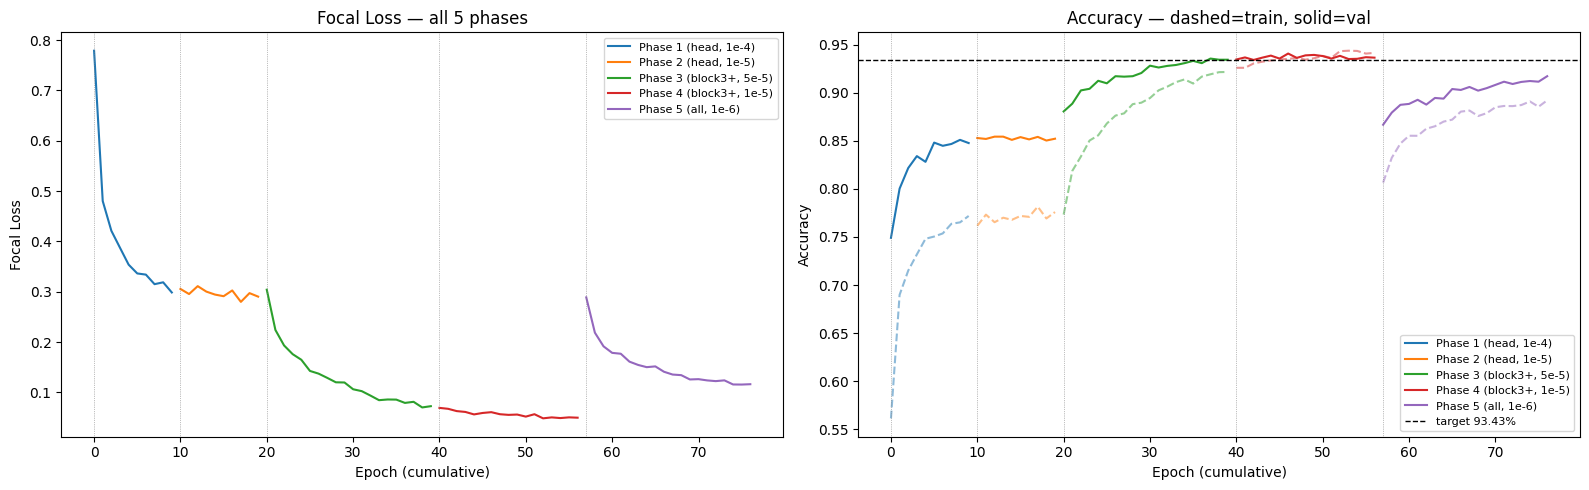

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
labels = [
    'Phase 1 (head, 1e-4)',
    'Phase 2 (head, 1e-5)',
    'Phase 3 (block3+, 5e-5)',
    'Phase 4 (block3+, 1e-5)',
    'Phase 5 (all, 1e-6)',
]

offset = 0
for h, label, color in zip(all_history, labels, colors):
    xs = list(range(offset, offset + len(h['train_losses'])))
    axes[0].plot(xs, h['train_losses'], color=color, label=label)
    axes[1].plot(xs, h['train_metrics'], color=color, linestyle='--', alpha=0.5)
    axes[1].plot(xs, h['valid_metrics'],  color=color, label=label)
    for ax in axes:
        ax.axvline(x=offset, color='grey', linewidth=0.5, linestyle=':')
    offset += len(h['train_losses'])

axes[0].set_title('Focal Loss — all 5 phases')
axes[0].set_xlabel('Epoch (cumulative)')
axes[0].set_ylabel('Focal Loss')
axes[0].legend(fontsize=8)

axes[1].set_title('Accuracy — dashed=train, solid=val')
axes[1].set_xlabel('Epoch (cumulative)')
axes[1].set_ylabel('Accuracy')
axes[1].axhline(y=0.9343, color='black', linewidth=1.0, linestyle='--', label='target 93.43%')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

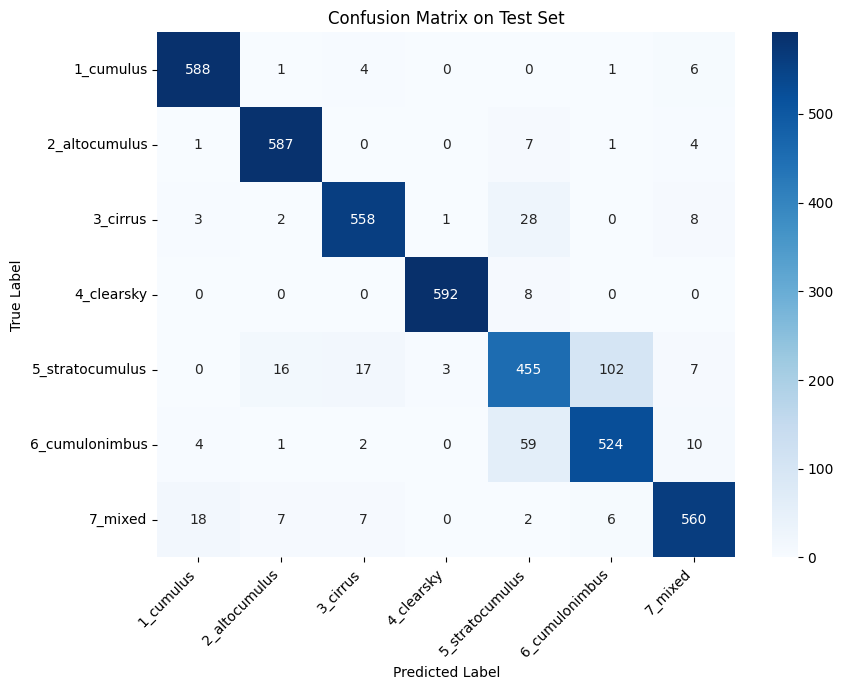

In [14]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds = torch.argmax(model(X_batch), dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())

cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()